# Picking diverse molecules from a library using fingerprints

* https://www.rdkit.org/docs/GettingStartedInPython.html#picking-diverse-molecules-using-fingerprints

* SimDivPicker
* https://www.rdkit.org/docs/source/rdkit.SimDivFilters.SimilarityPickers.html

fingerprints는 분자를 숫자의 리스트 혹은 비트 벡터(0 혹은 1) 리스트로 변환해서 서로간의 유사도를  빠르게 계산하는 도구

- MaxMinPicker 명령어

In [4]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3)
from rdkit import DataStructs
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker
# SimDivFilter.rdSimDivPickers => similarity or diversity를 기반으로 여러 분자들을 pick 해주는 모듈

* 압축 파일로부터 분자를 읽어들임.

In [6]:
import gzip
fin = gzip.open("data/actives_5ht3.sdf.gz")
mols = [m for m in Chem.ForwardSDMolSupplier(fin) if m is not None]

- 위에는 구버전이고 아래가 최신 버전인데 위와 같은 명령어가 되려면 다음과 같아야한다.

with gzip.open("data/actives_5ht3.sdf.gz") as fin:
    with Chem.ForwardSDMolSupplier(fin) as suppl:
       mols = [m for m in suppl if m is not None]

- 원래는 아래와 같은데, 위의 방식으로 하는 이유는

Chem.SDMolSupplier가 gz을 직접 처리하지 못하기 때문에 gzip.open을 통해 압축 파일 스트림 (fin)을 먼저 연다. 이 스트림을 ForwardSDMolSupplier에 전달하여 SDF 구조 데이터를 순차적으로 읽어들이고(suppl), 그중 오류가 없는 유효한 분자 객체(not None)들만 골라 mos라는 리스트에 최종 저장.


* fin : (변수) 파일 스트림, 압축된 파일을 읽을 수 있는 통로(스트림)

* suppl : (변수) 데이터 공급자, fin 통로를 통해 들어오는 데이터를 RDKit이 이해할 수 있는 분자(Mol) 객체로 하나씩 변환해주는 '공급 장치'. 압축 풀린 텍스트 데이터를 하나씩 가져와 분자로 변환해서 넘겨주는 역할

* mols : (리스트) 최종 저장소

with Chem.SDMolSupplier('data/actives_5ht3.sdf.gz') as suppl:
  ms = [x for x in suppl if x is not None]

++ 추가 설명 ++

Chem.ForwardSDMolSupplier는 기본적으로 SDF 형식을 읽기 위한 전용 도구 (.sdf 파일 혹은 .mol 파일)

다른 형식을 읽고 싶을땐?

SMILES 형식(.smi) => Chem.SmilesMolSupplier
PDB 형식 (.pdb) => Chem.MolFromPDBFile

여기서 SMILES와 PDB를 읽을 때 다른 명령어를 사용하는 이유는
Supplier는 여러 개(list)를 줄지어 읽을 때 사용하고, MolFrom...은 딱 하나(Single)를 읽을 때 쓰기 때문!

SDF 혹은 SMILES(.smi) 파일은 수백, 수천 개의 화합물을 한 파일에서 관리하니까 공급자(Supplier)가 필요한 반면 PDB 파일은 보통 단백질 하나나 복합체 하나를 정밀하게 묘사하기때문에, 파일 하나 당 분자 하나인 경우가 대다수. 만약 PDB도 여러 개라면 supplier를 사용해야한다. (다만 실무에서는 드문 편.)

In [7]:
len(mols)

180

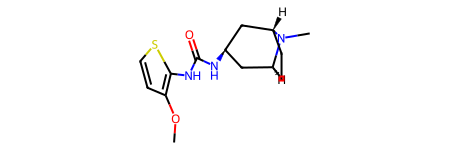

In [8]:
mols[0]

In [10]:
# 현재 3차원 구조를 반영한 구조식이라 보기편게하기 위해 2차원 구조로 변환
# 2D coordiate를 만드는 모듈은 AllChem 모듈에 존재해서 AllChem 모듈 불러들이기
from rdkit.Chem import AllChem

# 분자의 2차원 좌표를 얻을 수 있다.
AllChem.Compute2DCoords(mols[0])

0

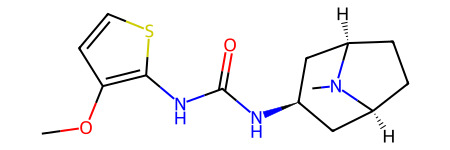

In [12]:
mols[0]

## 180개 분자에서 최대한 다양하게 10개의 분자를 추려내는 방법.

In [14]:
fps = [fpgen.GetFingerprint(x) for x in mols]

In [15]:
fps[0]

# Troubleshooting
강의는 SparseIntVect(Count Fingerprint) 형식으로 출력되었고 나는 ExplicitBitVect로 출련된 이유

- 강의 코드 (구 버전)

  GetMorganFingerprint(x,3)을 사용함.
  => Count 기반의 fingerprints 생성하며 결과물로 UlntSparseIntVect 반환함. (구조의 개수 정보 포함)
UlntSparseIntVect는 MaxMinPicker, DatStructs, Dice 유사도나 개수 기반 비교할때 자주 사용됨.

- 내 코드 (최신 버전)
  fpgen.GetFingerprint(x) 사용.
  => FingerprintGenerator에서 GetFingerpritn를 쓰면 기본적으로 Bit 기반(0 또는 1)의 ExplicitBitVect 반환.
ExplicitBitVect는 MaxMinPicker, DataSructs, Tanimoto 유사도를 계산할 때 자주 사용됨.


최신 버전에서 강의와 똑같이 맞추고싶다면 (구조의 개수 정보를 포함하고 싶다면 다음과 같은 명령어로 수정)

기존: fps = [fpgen.GetFingerprint(x) for x in mols]
변경: fps = [fpgen.GetCountFingerprint(x) for x in mols]

In [17]:
fpss = [fpgen.GetCountFingerprint(x) for x in mols]

In [18]:
fpss[0]

In [19]:
# 사용할수 있는 method가 궁금할 때 dir() 함수를 이용한다.
dir(fpss[0])

['GetLength',
 'GetNonzeroElements',
 'GetTotalVal',
 'ToBinary',
 'ToList',
 'UpdateFromSequence',
 '__add__',
 '__and__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getinitargs__',
 '__getitem__',
 '__getstate__',
 '__getstate_manages_dict__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__idiv__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__instance_size__',
 '__isub__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__safe_for_unpickling__',
 '__setattr__',
 '__setitem__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__sub__',
 '__subclasshook__',
 '__weakref__']

In [20]:
# ____로 시작하는 것들: 파이썬 내부 처리를 위한 특수 method. (보통은 직접 쓸 일이 많지 않음)
# 일반 단어로 시작하는 것들: 우리가 실제로 사용할 수 있는 기능.
    # 예를 들어, GetNumOnBits가 목록에 있다면 fps[0].GetNumOnBits()라고 써서 "1로 표시된 비트가 몇 개인지" 확인할 수 있음.

- 2026년 버전으로 method와 간략한 설명이 필요할 때 두개를 조합해서 사용할 수 있다.

dir(fps[0]): 전체 method을 알고싶을 때

help(fps[0].GetNumOnBits) : dir()에서 알게된 method 중 GetNumOnBits에 대한 상세 설명과 사용법을 알고 싶을 때

In [24]:
dir(fps[0])

['FromBase64',
 'GetBit',
 'GetNumBits',
 'GetNumOffBits',
 'GetNumOnBits',
 'GetOnBits',
 'SetBit',
 'SetBitsFromList',
 'ToBase64',
 'ToBinary',
 'ToBitString',
 'ToList',
 'UnSetBit',
 'UnSetBitsFromList',
 '__add__',
 '__and__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getinitargs__',
 '__getitem__',
 '__getstate__',
 '__getstate_manages_dict__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__init__',
 '__init_subclass__',
 '__instance_size__',
 '__invert__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__safe_for_unpickling__',
 '__setattr__',
 '__setitem__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '__xor__']

In [21]:
help(fps[0].GetNumOnBits)

Help on method GetNumOnBits:

GetNumOnBits(...) method of rdkit.DataStructs.cDataStructs.ExplicitBitVect instance
    GetNumOnBits( (ExplicitBitVect)self) -> int :
        Returns the number of on bits.
        
    
        C++ signature :
            unsigned int GetNumOnBits(class ExplicitBitVect {lvalue})



In [25]:
fps[0].GetNonzeroElements()

AttributeError: 'ExplicitBitVect' object has no attribute 'GetNonzeroElements'

# Troubleshooting

fps[0]의 벡터 파일로 사용할 수 있는 method 목록에 GetNonzeroElements가 없기 때문

이는 아마 fpss[0]와 fps[0]가 다른 형식의 벡터로 저장되어있기 때문일 것으로 생각함.. 

=> 맞음 아래 설명 참고


* 용어 정리

- 방식(Representation)

ExplicitBitVect와 UlnSparseInVect는 fingerprints를 표현하는 데이터 타입(형식)

- 메서드(Method)

fpgen.GetFingerprint()와 fpgen.GetCountFingerprint()는 특정 형식의 데이터를 만들어내기 위해 호출하는 '함수(메서드)'


* 왜 사용 가능한 method가 다른가?

=> 데이터의 '성질'이 다르기 때문

- ExplicitBitVect (비트 방식): 0 또는 1만 가지기 때문에, GetNumOnBits(1인 개수), SetBit(특정 칸을 1로 만들기)처럼 '비트'를 다루는 용어들이 나타납니다.

- UIntSparseIntVect (카운트 방식): 0, 1, 2, 3... 처럼 개수를 가지기 때문에, 비트처럼 단순히 켜고 끄는 게 아니므로 GetTotalVal(모든 칸의 숫자 합계), GetNonzeroElements(0이 아닌 칸들의 정보)처럼 '수치'와 '양'을 다루는 용어들이 나타남.

In [27]:
# 0이 아닌 칸들의 정보
fpss[0].GetNonzeroElements()

{1: 1,
 14: 1,
 50: 1,
 181: 1,
 209: 1,
 249: 1,
 271: 1,
 338: 2,
 387: 1,
 423: 1,
 425: 1,
 551: 2,
 554: 1,
 650: 1,
 675: 1,
 695: 1,
 753: 1,
 807: 1,
 816: 1,
 820: 1,
 838: 1,
 841: 1,
 926: 4,
 935: 1,
 1018: 1,
 1019: 3,
 1050: 2,
 1057: 2,
 1132: 1,
 1145: 1,
 1152: 2,
 1292: 2,
 1325: 2,
 1367: 1,
 1380: 2,
 1434: 1,
 1497: 1,
 1536: 1,
 1567: 1,
 1634: 1,
 1639: 1,
 1685: 1,
 1750: 1,
 1758: 1,
 1804: 1,
 1816: 1,
 1871: 1,
 1873: 2,
 1910: 2,
 1917: 1,
 1923: 2,
 1970: 1,
 1989: 1,
 2028: 2,
 2041: 1}

# Troubleshooting

FingerprintGenerator와 GetMoranFingerprint의 차이때문

1. fingerprints(ID) 범위 차이


   강의(구버전, GetMorganFingerprint): 기본적으로 비트 크기 제한이 없는(Unbound) 정수 값을 생성. (분자의 각 조각에 고유한 정수 번호를 무작위로 부여하는 방식)


   나(최신버전, GetMorganGenerator): 별도로 설정하지 않으면 기본적으로 2048비트(fpSize=2048)라는 고정된 크기 안에서 번호를 매김. 때문에 0부터 2047번 사이의 방에 조각들을 차곡차곡 채워 넣는 방식이라 숫자가 작고 깔끔함.
   
2. 고정 크기(Folded) vs 가변 그키
    강의: 조각이 발견될 때마다 무조건 모든 조각에 고유 번호를 부여. 이론산 번호의 범위가  무한대

    나: rdFingerprintGenerator.GetMorganGenerator(radius=3)는 내부적으로 해싱과정을 거쳐 수많은 화학 구조 조각들을 2048개의 방 안에 골고루 나눠 담는 과정에서 번호가 재할당됨.
   
4. 결과의 의미는 같다.

In [29]:
len(fpss)

180

# distij 함수

- 이 코드가 "서로 닮지 않음"을 정의.
  
- DiceSimilarity가 유사도(얼마나 닮았나)라면, 1 - 유사도는 거리(얼마나 먼가/다른가)가 됨.

- 즉, 이 함수는 두 분자가 다를수록 큰 숫자를 뱉어낸다.

- 쉬운 예시

  80명이 모인 운동장에서 가장 성격이 다른 10명을 뽑는 상황과 같습니다.
  일단 랜덤으로 1명을 뽑습니다 (seed=100).
  그 다음에는 이미 뽑힌 사람과 가장 성격이 다른(거리가 먼) 사람을 찾아서 2번째로 뽑습니다.
  3번째 사람은 1번, 2번 사람 모두와 비교했을 때 가장 성격이 골고루 다른 사람을 뽑습니다.
  이 과정을 10명이 될 때까지 반복합니다.
  결과적으로 이 10명은 전체 180명의 다양한 특징을 골고루 대변하게 됩니다.

In [40]:
# i와 j를 input으로 받아서 i번째와 j번째 분자의 distance를 계산하는 함수.
def distij(i,j,fpss=fpss):
  return 1-DataStructs.DiceSimilarity(fpss[i],fpss[j])

# def distij(i,j,fps=fps):
    # fps=fps 의미: argument를 주지 않으면 기본적으로 fps라는 리스트를 사용하겠다.

# return 1-DataStructs.DiceSimilarity(fps[i],fps[j])
    # i번째와 j번째 fps 리스트에서 DiceSimilarity를 계산해서 1에서 빼주겠다. 즉, 거리 = 1- 유사도

In [41]:
# MaxMinPicker 알고리즘을 수행하는 instance 생성
picker = MaxMinPicker()

In [42]:
picker

LazyPick(
(MaxMinPicker)self : 정의하지 않으면 MaxMinPicker로 실행됨.

(rdkit.Chem.rdMolDescriptors.AtomPairsParameters)distFunc : dist 함수 (여기서는 이전에 정의한 distij)

(int)poolSize : 전체 라이브러리 (분자의 pool) 안에 몇개가 있느냐

(int)pickSize : pool 중에서 몇개를 고를거냐

(int)seed : 대부분의 picking하는 알고리즘들의 경우, 처음에 무작위한 상태에서 시작해서 조금씩 정교하게 만들어나가는 과정을 포함하기 때문에 seed 옵션을 사용한다.
: (optional) seed for the random number generator
: seed를 주지 않으면 계산할때마다 다른 값을 얻을 수 있는데 seed를 주면 계산할때마다 똑같은 값을 얻을 수 있다.
아래의 곽괄호는 선택사항

[,rdkit.Chem.rdMolDescriptors.AtomPairsParameters)firstPicks=()[, (int)seed=-1[, (rdkit.Chem.rdMolDescriptors.AtomPairsParameters)useCache=None]]])

그 결과는 아래와 같이 나온다.
→ rdkit.rdBase._vecti :

참고로 int = 정수 형태의 숫자

In [43]:
# pickIndices(변수)로 받았음.
pickIndices = picker.LazyPick(distij,len(fpss),10,seed=100)

In [44]:
pickIndices

In [47]:
# 내 환경에서 선택된 10개의 분자 인덱스 확인하기
list(pickIndices)

[97, 41, 57, 151, 137, 6, 12, 158, 130, 99]

In [48]:
# 10개의 분자 인덱스를 (작-> 큰) 순서대로 확인하기
sorted(list(pickIndices))

[6, 12, 41, 57, 97, 99, 130, 137, 151, 158]

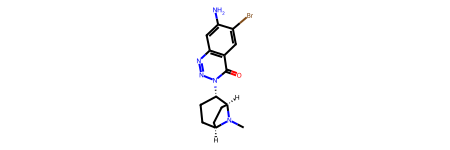

In [49]:
mols[6]

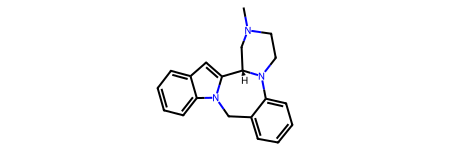

In [50]:
mols[12]

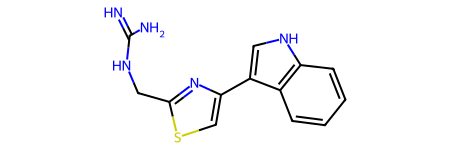

In [51]:
mols[41]

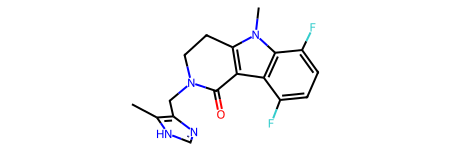

In [52]:
mols[57]

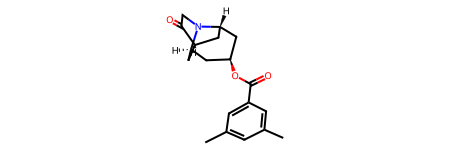

In [53]:
mols[97]

LazyPick() 함수가 MaxMinPicker라는 도구를 사용해서, distij라는 기준에 따라 180개 중 10개를 실제로 골라내는 주인공

# Generating Similarity Maps Using Fingerprints

In [54]:
# 두개의 분자가 있을때, 어디가 유사하고 어디가 다른지를 빠르게 눈으로 체크하는 루틴
mol = Chem.MolFromSmiles('COc1cccc2cc(C(=O)NCCCCN3CCN(c4cccc5nccnc54)CC3)oc21')
refmol = Chem.MolFromSmiles('CCCN(CCCCN1CCN(c2ccccc2OC)CC1)Cc1ccc2ccccc2c1')

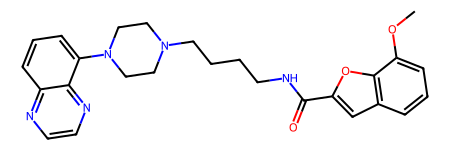

In [55]:
mol

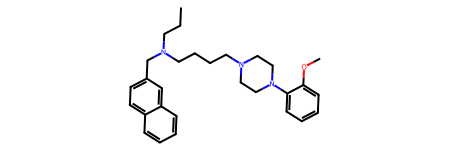

In [56]:
refmol

In [57]:
# 두개의 분자가 엇비슷하기 때문에 이것을 빠르게 확인하기 위해 Similarity Map을 그린다.
from rdkit.Chem import Draw # Map을 그리기 위해 불러와야하는 sub 모듈
from rdkit.Chem.Draw import SimilarityMaps

58부터 81은 최신 버전 제대로 구현 안된거

In [58]:
d2d = Draw.MolDraw2DCairo(400, 400)
_, maxweight = SimilarityMaps.GetSimilarityMapForFingerprint(refmol, mol, SimilarityMaps.GetMorganFingerprint, d2d)

[17:33:24] DEPRECATION WARNING: please use MorganGenerator
[17:33:24] DEPRECATION WARNING: please use MorganGenerator


In [59]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3)

d2d = Draw.MolDraw2DCairo(400, 400)
_, maxweight = SimilarityMaps.GetSimilarityMapForFingerprint(
    refmol, 
    mol, 
    lambda m, i=-1: fpgen.GetFingerprint(m, fromAtoms=[i] if i != -1 else None), 
    draw2d=d2d
)

In [60]:
d2d.FinishDrawing()

from rdkit.Chem import Draw
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import rdFingerprintGenerator # 최신 제너레이터 모듈

1. 최신 Morgan 제너레이터 생성 (radius 설정 가능)
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=3)

2. Similarity Map 그리기
 세 번째 인자에 함수 대신 생성기의 GetFingerprint 메서드를 직접 전달합니다.
d2d = Draw.MolDraw2DCairo(400, 400)
_, maxweight = SimilarityMaps.GetSimilarityMapForFingerprint(
    refmol, 
    mol, 
    lambda m, i=-1: fpgen.GetFingerprint(m, fromAtoms=[i] if i != -1 else None), 
    draw2d=d2d
)

3. 결과 확인
d2d.FinishDrawing()

4. 이미지로 출력
Image(d2d.GetDrawingText())

d2d.WriteDrawingText('similarity_map.png') # 파일로 저장 시

In [61]:
from rdkit.Chem import rdFingerprintGenerator

In [69]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=4)

In [73]:
d2d = Draw.MolDraw2DCairo(400, 400)
_, maxweight = SimilarityMaps.GetSimilarityMapForFingerprint(
    refmol, 
    mol, 
    lambda m, i=-1: fpgen.GetFingerprint(m, fromAtoms=[i] if i != -1 else None), # 이 부분이 핵심 수정!
    draw2d=d2d
)

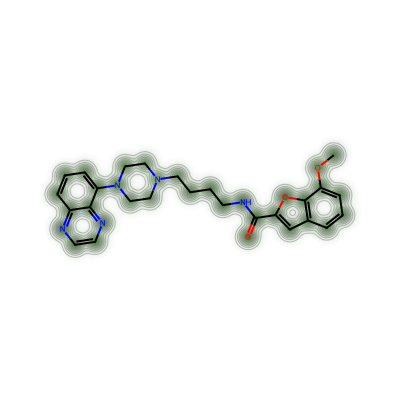

In [71]:
from IPython.display import Image

# 1. 그림 그리기가 끝났음을 선언 (d2d는 cairo 전용 도화지에 그림을 다 그렸는데 내 눈앞에 가져오라는 명령을 하지 않
d2d.FinishDrawing()

# 2. 메모리에 그려진 데이터를 이미지(PNG 등) 형태로 가져와 화면에 출력
Image(d2d.GetDrawingText())

In [101]:
fig, maxweight = SimilarityMaps.GetSimilarityMapForFingerprint(
    refmol, mol, fp_func
)
d2d = Draw.MolDraw2DCairo(400, 400)

fp_func = lambda m, idx: SimilarityMaps.GetMorganFingerprint(m, idx, radius=2, nBits=2048)

SimilarityMaps.GetSimilarityMapForFingerprint(
    refmol, mol, fp_func, draw2d=d2d
)

d2d.FinishDrawing()

TypeError: GetSimilarityMapForFingerprint() missing 1 required positional argument: 'draw2d'

In [77]:
# generator 모듈 import
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs

# 최신 Morgan generator 생성
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2)

# GetMorganFingerpinrt 부분을 fpgen으로 교체
_, maxweight = SimilarityMaps.GetSimilarityMapForFingerprint(
    refmol, 
    mol, 
    lambda m, i=-1: fpgen.GetFingerprint(m, fromAtoms=[i] if i != -1 else None), # 핵심 수정!
    draw2d=d2d, 
    metric=DataStructs.TanimotoSimilarity
)

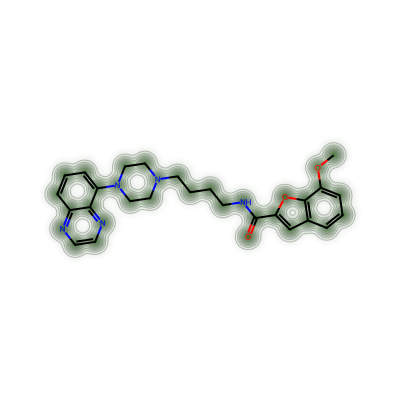

In [78]:
# 결과 출력
d2d.FinishDrawing()
from IPython.display import Image
Image(d2d.GetDrawingText())

In [84]:
# 1. 제너레이터 설정 (radius=2 정도가 시각적으로 적당합니다)
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2)

# 2. 고해상도 Cairo 도화지 준비
d2d = Draw.MolDraw2DCairo(400, 400)

# 3. 강의 스타일 옵션 추가
_, maxweight = SimilarityMaps.GetSimilarityMapForFingerprint(
    refmol, 
    mol, 
    lambda m, i=-1: fpgen.GetFingerprint(m, fromAtoms=[i] if i != -1 else None), 
    draw2d=d2d, 
    metric=DataStructs.TanimotoSimilarity,
    # --- 여기서부터 강의 스타일 설정 ---
    contourLines=10,    # 강의처럼 진한 '등고선'을 10줄 추가합니다.
    alpha=0.6,          # 배경 색상을 더 진하게 만듭니다 (0.0~1.0).
    sigma=0.15           # 색이 번지는 범위를 좁혀서 '핵심 부위'만 강조합니다.
)

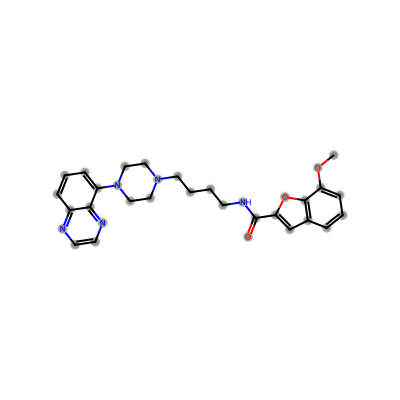

In [85]:
# 4. 결과 출력
d2d.FinishDrawing()
from IPython.display import Image
Image(d2d.GetDrawingText())

In [81]:
fig, maxweight = SimilarityMaps.GetSimilarityMapForFingerprint(refmol, mol, SimilarityMaps.fpgen.GetFingerprint)

AttributeError: module 'rdkit.Chem.Draw.SimilarityMaps' has no attribute 'fpgen'

In [88]:
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Draw import SimilarityMaps

# 1. 최신 Morgan 제너레이터 생성 (강의와 동일하게 radius=2 설정)
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2)

# 2. Similarity Map 생성 (가장 권장되는 방식)
# 세 번째 인자에 lambda를 사용하여 최신 제너레이터와 연결합니다.
fig, maxweight = SimilarityMaps.GetSimilarityMapForFingerprint(
    refmol, 
    mol, 
    lambda m, i=-1: fpgen.GetFingerprint(m, fromAtoms=[i] if i != -1 else None)
    draw2d=d2d,
    metric=DataStructs.TanimotoSimilarity,
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2716635205.py, line 12)

* 89~104번이 잘 된거고 위는 최신과 구식의 차이에 의해 발생한 오류.

In [89]:
from rdkit import Chem
mol = Chem.MolFromSmiles('COc1cccc2cc(C(=O)NCCCCN3CCN(c4cccc5nccnc54)CC3)oc21')
refmol = Chem.MolFromSmiles('CCCN(CCCCN1CCN(c2ccccc2OC)CC1)Cc1ccc2ccccc2c1')

In [90]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import SimilarityMaps

In [102]:
fp_func = lambda m, idx: SimilarityMaps.GetMorganFingerprint(m, idx, radius=2, nBits=2048)
fig, maxweight = SimilarityMaps.GetSimilarityMapForFingerprint(
    refmol, mol, fp_func
)

TypeError: GetSimilarityMapForFingerprint() missing 1 required positional argument: 'draw2d'

[18:37:56] DEPRECATION WARNING: please use MorganGenerator
[18:37:56] DEPRECATION WARNING: please use MorganGenerator


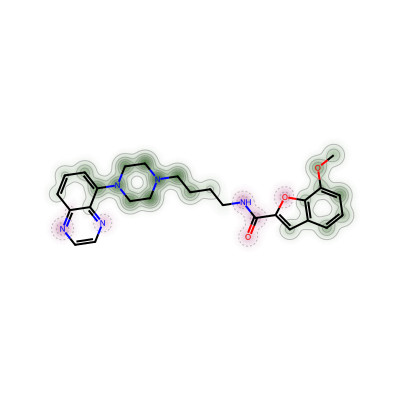

In [104]:
# draw 객체 생성
d2d = Draw.MolDraw2DCairo(400, 400)
# 🔥 fingerprint 함수 명시
fp_func = lambda m, idx: SimilarityMaps.GetMorganFingerprint(m, idx, radius=2, nBits=2048)

# 🔥 반드시 draw2d 넣어야 함 (최신 RDKit에서는 GetSimilarityMapForFingerprint()가 반드시 draw2d 객체를 요구함)
SimilarityMaps.GetSimilarityMapForFingerprint(
    refmol,
    mol,
    fp_func,
    draw2d=d2d
)
# 마무리
d2d.FinishDrawing()

# 출력 (Jupyter)
from IPython.display import Image
Image(d2d.GetDrawingText())

# Descriptor calculation

- https://www.rdkit.org/docs/GettingStartedInPython.html#descriptor-calculation

Descriptor: 분자의 특정 성질 또는 종합적인 구조/성질을 숫자로 나타내는 것.

* 두군데의 sub-module에 정의되어 있음: Descriptor / rdMolDescriptor

* 분자의 물성에 맞춰서 하나의 실수값으로 바꾸는 Discriptor 위주로 진행할 예정

In [106]:
from rdkit.Chem import Descriptors, rdMolDescriptors

In [107]:
m = Chem.MolFromSmiles('c1ccccc1C(=O)O')

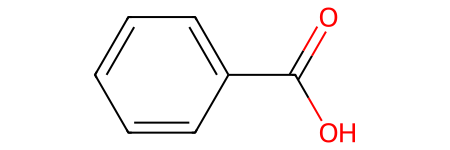

In [108]:
m

In [109]:
# TPSA(Total polar surface area) 값이 크면 클수록 물과 interaction 할 수 있는 부분이 많다(polar 하다)는 것을 의미
Descriptors.TPSA(m)

37.3

* Descriptors 모듈 안에 존재하는 전체 Method list를 확인

In [110]:
dir(Descriptors)

['AUTOCORR2D_1',
 'AUTOCORR2D_10',
 'AUTOCORR2D_100',
 'AUTOCORR2D_101',
 'AUTOCORR2D_102',
 'AUTOCORR2D_103',
 'AUTOCORR2D_104',
 'AUTOCORR2D_105',
 'AUTOCORR2D_106',
 'AUTOCORR2D_107',
 'AUTOCORR2D_108',
 'AUTOCORR2D_109',
 'AUTOCORR2D_11',
 'AUTOCORR2D_110',
 'AUTOCORR2D_111',
 'AUTOCORR2D_112',
 'AUTOCORR2D_113',
 'AUTOCORR2D_114',
 'AUTOCORR2D_115',
 'AUTOCORR2D_116',
 'AUTOCORR2D_117',
 'AUTOCORR2D_118',
 'AUTOCORR2D_119',
 'AUTOCORR2D_12',
 'AUTOCORR2D_120',
 'AUTOCORR2D_121',
 'AUTOCORR2D_122',
 'AUTOCORR2D_123',
 'AUTOCORR2D_124',
 'AUTOCORR2D_125',
 'AUTOCORR2D_126',
 'AUTOCORR2D_127',
 'AUTOCORR2D_128',
 'AUTOCORR2D_129',
 'AUTOCORR2D_13',
 'AUTOCORR2D_130',
 'AUTOCORR2D_131',
 'AUTOCORR2D_132',
 'AUTOCORR2D_133',
 'AUTOCORR2D_134',
 'AUTOCORR2D_135',
 'AUTOCORR2D_136',
 'AUTOCORR2D_137',
 'AUTOCORR2D_138',
 'AUTOCORR2D_139',
 'AUTOCORR2D_14',
 'AUTOCORR2D_140',
 'AUTOCORR2D_141',
 'AUTOCORR2D_142',
 'AUTOCORR2D_143',
 'AUTOCORR2D_144',
 'AUTOCORR2D_145',
 'AUTOCORR2D_146',


In [111]:
dir(rdMolDescriptors)

['AtomPairsParameters',
 'BCUT2D',
 'CalcAUTOCORR2D',
 'CalcAUTOCORR3D',
 'CalcAsphericity',
 'CalcChi0n',
 'CalcChi0v',
 'CalcChi1n',
 'CalcChi1v',
 'CalcChi2n',
 'CalcChi2v',
 'CalcChi3n',
 'CalcChi3v',
 'CalcChi4n',
 'CalcChi4v',
 'CalcChiNn',
 'CalcChiNv',
 'CalcCoulombMat',
 'CalcCrippenDescriptors',
 'CalcEEMcharges',
 'CalcEccentricity',
 'CalcExactMolWt',
 'CalcFractionCSP3',
 'CalcGETAWAY',
 'CalcHallKierAlpha',
 'CalcInertialShapeFactor',
 'CalcKappa1',
 'CalcKappa2',
 'CalcKappa3',
 'CalcLabuteASA',
 'CalcMORSE',
 'CalcMolFormula',
 'CalcNPR1',
 'CalcNPR2',
 'CalcNumAliphaticCarbocycles',
 'CalcNumAliphaticHeterocycles',
 'CalcNumAliphaticRings',
 'CalcNumAmideBonds',
 'CalcNumAromaticCarbocycles',
 'CalcNumAromaticHeterocycles',
 'CalcNumAromaticRings',
 'CalcNumAtomStereoCenters',
 'CalcNumAtoms',
 'CalcNumBridgeheadAtoms',
 'CalcNumHBA',
 'CalcNumHBD',
 'CalcNumHeavyAtoms',
 'CalcNumHeteroatoms',
 'CalcNumHeterocycles',
 'CalcNumLipinskiHBA',
 'CalcNumLipinskiHBD',
 'Calc

- LogP 계산

  logP는 화합물의 친유성(Lipophilicity)을 나타내는 지표

  정확히는 물과 옥탄올(기름 성질) 섞이지 않는 두 액체 사이에 화합물을 넣었을 때, 어느 쪽에 더 많이 녹아 들어가는지를 수치화한 값의 로그값

  수치의 의미: 값이 클수록 기름에 잘 녹고(친유성), 값이 작거나 음수일수록 물에 잘 녹는다(친수성).

  약물 설계에서 중요성: 약이 체내 세포막(지질 성분)을 얼마나 잘 통과할 수 있을지 예측하는데 쓰인다. 너무 높으면 물에 안 녹아서 흡수가 안 되고, 너무 낮으면 세포막을 못 통과한다.

  Wildman-Crippen 방식: RDKit은  실험값이 아닌, 분자 구조를 조각내어 각 원자 기여도를 합산 하는 Wildman-Crippen 알고리즘으로 이 값을 계산(MolLogP)한다.

In [115]:
Descriptors.MolLogP(m) # 실험값이 아닌 rdkit에 구현되있는 logP 예측 알고리즘을 이용해서 계산

1.3848

In [117]:
# method 중 'BalabanJ'로 계산
# BalabanJ = 분자가 얼마나 복잡하게 생겼느냐, Branch가 얼나 많은가?를 간접적으로 표현하는 수치
Descriptors.BalabanJ(m)

2.98145461404113

In [125]:
# method 중 'FractionCSP3'로 계산
Descriptors.FractionCSP3(m) #sp3 carbon의 fraction.

0.0

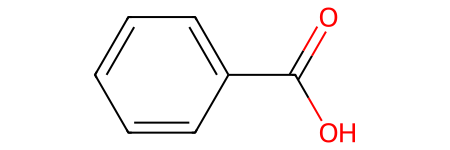

In [119]:
m # m에는 sp3 carbon이 없기 때문에 0이 나온것.

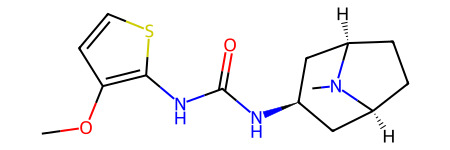

In [120]:
mols[0]

In [121]:
Descriptors.FractionCSP3(mols[0]) # carbon 중에 64%가 sp3 carbon이라는 의미.

0.6428571428571429

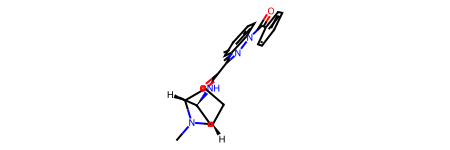

In [124]:
mols[1]

In [123]:
Descriptors.FractionCSP3(mols[1]) # carbon 중에 34%가 sp3 carbon이라는 의미.

0.34782608695652173

In [127]:
# method 중 'RingCount'로 계산, ring 구조의 개수
Descriptors.RingCount(mols[0])

3

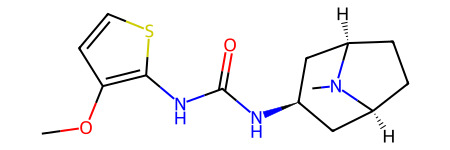

In [129]:
mols[0] #링이 3개

- functional group의 개수를 알고 싶을때
Descriptors.fr_(name of functional group)()

In [130]:
# method 중 'fr_imide'로 계산, imide functional group의수
Descriptors.fr_imide(mols[0])

0

In [131]:
# method 중 'fr_phenol'로 계산, phenol functional group의수
Descriptors.fr_phenol(mols[0])

0

* QED: https://www.nature.com/articles/nchem.1243

* 얼마나 기존에 알려진 약과 유사한 물성을 가지고 있는가? (8가지의 물성에 기반해서)

* MW, Hydrogenbond acceptor/donor 개수, rotatable bond 개수, ring 개수, logP 등등을 고려해서

* 0~1 사이로 계산이 됨.

* 0에 가까우면 기존에 알려진 약과 많이 다르다. 1에 가까우면 기존의 알려진 약과 유사한 물성을 가지고 있다.

In [132]:
# method 중 'qed'로 계산
Descriptors.qed(m)

0.6106035394285075

# 주어진 분자에서 rdkit에서 계산 가능한 실수(float)로 주어지는 descriptor들의 list를 return함.

In [88]:
from rdkit import DataStructs
from rdkit.Chem import MolFromSmiles
from rdkit.Chem.GraphDescriptors import (BalabanJ, BertzCT, Chi0, Chi0n, Chi0v, Chi1,
                                         Chi1n, Chi1v, Chi2n, Chi2v, Chi3n, Chi3v, Chi4n, Chi4v,
                                         HallKierAlpha, Ipc, Kappa1, Kappa2, Kappa3)

from rdkit.Chem.EState.EState_VSA import (EState_VSA1, EState_VSA10, EState_VSA11, EState_VSA2, EState_VSA3,
                                          EState_VSA4, EState_VSA5, EState_VSA6, EState_VSA7, EState_VSA8, EState_VSA9,
                                          VSA_EState1, VSA_EState10, VSA_EState2, VSA_EState3, VSA_EState4, VSA_EState5,
                                          VSA_EState6, VSA_EState7, VSA_EState8, VSA_EState9,)

from rdkit.Chem.Descriptors import (ExactMolWt, MolWt, HeavyAtomMolWt, MaxAbsPartialCharge, MinPartialCharge,
                                    MaxPartialCharge, MinAbsPartialCharge, NumRadicalElectrons, NumValenceElectrons)

from rdkit.Chem.EState.EState import (MaxAbsEStateIndex, MaxEStateIndex, MinAbsEStateIndex, MinEStateIndex,)

from rdkit.Chem.Lipinski import (FractionCSP3, HeavyAtomCount, NHOHCount, NOCount, NumAliphaticCarbocycles,
                                 NumAliphaticHeterocycles, NumAliphaticRings, NumAromaticCarbocycles, NumAromaticHeterocycles,
                                 NumAromaticRings, NumHAcceptors, NumHDonors, NumHeteroatoms, RingCount,
                                 NumRotatableBonds, NumSaturatedCarbocycles, NumSaturatedHeterocycles, NumSaturatedRings,)

from rdkit.Chem.Crippen import (MolLogP, MolMR, )

from rdkit.Chem.MolSurf import (LabuteASA, PEOE_VSA1, PEOE_VSA10, PEOE_VSA11, PEOE_VSA12, PEOE_VSA13, PEOE_VSA14,
                                PEOE_VSA2, PEOE_VSA3,PEOE_VSA4, PEOE_VSA5, PEOE_VSA6, PEOE_VSA7, PEOE_VSA8, PEOE_VSA9,
                                SMR_VSA1, SMR_VSA10, SMR_VSA2, SMR_VSA3, SMR_VSA4, SMR_VSA5, SMR_VSA6,
                                SMR_VSA7, SMR_VSA8, SMR_VSA9, SlogP_VSA1, SlogP_VSA10, SlogP_VSA11, SlogP_VSA12,
                                SlogP_VSA2, SlogP_VSA3,SlogP_VSA4, SlogP_VSA5, SlogP_VSA6, SlogP_VSA7, SlogP_VSA8,
                                SlogP_VSA9, TPSA, )

from rdkit.Chem.Fragments import (fr_Al_COO, fr_Al_OH, fr_Al_OH_noTert, fr_ArN, fr_Ar_COO, fr_Ar_N, fr_Ar_NH,
 fr_Ar_OH, fr_COO, fr_COO2, fr_C_O, fr_C_O_noCOO, fr_C_S, fr_HOCCN, fr_Imine, fr_NH0, fr_NH1,
 fr_NH2, fr_N_O, fr_Ndealkylation1, fr_Ndealkylation2, fr_Nhpyrrole, fr_SH, fr_aldehyde, fr_alkyl_carbamate,
 fr_alkyl_halide, fr_allylic_oxid, fr_amide, fr_amidine, fr_aniline, fr_aryl_methyl, fr_azide, fr_azo, fr_barbitur,
 fr_benzene, fr_benzodiazepine, fr_bicyclic, fr_diazo, fr_dihydropyridine, fr_epoxide, fr_ester, fr_ether, fr_furan,
 fr_guanido, fr_halogen, fr_hdrzine, fr_hdrzone, fr_imidazole, fr_imide, fr_isocyan, fr_isothiocyan, fr_ketone,
 fr_ketone_Topliss, fr_lactam, fr_lactone, fr_methoxy, fr_morpholine, fr_nitrile, fr_nitro, fr_nitro_arom,
 fr_nitro_arom_nonortho, fr_nitroso, fr_oxazole, fr_oxime, fr_para_hydroxylation, fr_phenol,
 fr_phenol_noOrthoHbond, fr_phos_acid, fr_phos_ester, fr_piperdine, fr_piperzine, fr_priamide, fr_prisulfonamd,
 fr_pyridine, fr_quatN, fr_sulfide, fr_sulfonamd, fr_sulfone, fr_term_acetylene, fr_tetrazole, fr_thiazole, fr_thiocyan,
 fr_thiophene, fr_unbrch_alkane, fr_urea)

def get_descriptors(mol):
    if mol is None:
        print("Molecule is None!")
        
    else:
        AllChem.ComputeGasteigerCharges(mol)
        finger = [
            BalabanJ(mol) , # 0
            BertzCT(mol) , # 1
            Chi0(mol) , # 2
            Chi0n(mol) , # 3
            Chi0v(mol) , # 4
            Chi1(mol) , # 5
            Chi1n(mol) , # 6
            Chi1v(mol) , # 7
            Chi2n(mol) ,
            Chi2v(mol) ,
            Chi3n(mol) ,
            Chi3v(mol) ,
            Chi4n(mol) ,
            Chi4v(mol) ,
            EState_VSA1(mol) ,
            EState_VSA10(mol) ,
            EState_VSA11(mol) ,
            EState_VSA2(mol) ,
            EState_VSA3(mol) ,
            EState_VSA4(mol) ,
            EState_VSA5(mol) ,
            EState_VSA6(mol) ,
            EState_VSA7(mol) ,
            EState_VSA8(mol) ,
                EState_VSA9(mol) ,
                ExactMolWt(mol) ,
                FractionCSP3(mol) ,
                HallKierAlpha(mol) ,
                HeavyAtomCount(mol) ,
                HeavyAtomMolWt(mol) ,
                # Ipc(mol) ,
                Kappa1(mol) ,
                Kappa2(mol) ,
                Kappa3(mol) ,
                LabuteASA(mol) ,
                MaxAbsEStateIndex(mol) ,
                MaxAbsPartialCharge(mol) ,
                MaxEStateIndex(mol) ,
                MaxPartialCharge(mol) ,
                MinAbsEStateIndex(mol) ,
                MinAbsPartialCharge(mol) ,
                MinEStateIndex(mol) ,
                MinPartialCharge(mol) ,
                MolLogP(mol) ,
                MolMR(mol) ,
                MolWt(mol) ,
                NHOHCount(mol) ,
                NOCount(mol) ,
                NumAliphaticCarbocycles(mol) ,
                NumAliphaticHeterocycles(mol) ,
                NumAliphaticRings(mol) ,
                NumAromaticCarbocycles(mol) ,
                NumAromaticHeterocycles(mol) ,
                NumAromaticRings(mol) ,
                NumHAcceptors(mol) ,
                NumHDonors(mol) ,
                NumHeteroatoms(mol) ,
                NumRadicalElectrons(mol) ,
                NumRotatableBonds(mol) ,
                NumSaturatedCarbocycles(mol) ,
                NumSaturatedHeterocycles(mol) ,
                NumSaturatedRings(mol) ,
                NumValenceElectrons(mol) ,
                PEOE_VSA1(mol) ,
                PEOE_VSA10(mol) ,
                PEOE_VSA11(mol) ,
                PEOE_VSA12(mol) ,
                PEOE_VSA13(mol) ,
                PEOE_VSA14(mol) ,
                PEOE_VSA2(mol) ,
                PEOE_VSA3(mol) ,
                PEOE_VSA4(mol) ,
                PEOE_VSA5(mol) ,
                PEOE_VSA6(mol) ,
                PEOE_VSA7(mol) ,
                PEOE_VSA8(mol) ,
                PEOE_VSA9(mol) ,
                RingCount(mol) ,
                SMR_VSA1(mol) ,
                SMR_VSA10(mol) ,
                SMR_VSA2(mol) ,
                SMR_VSA3(mol) ,
                SMR_VSA4(mol) ,
                SMR_VSA5(mol) ,
                SMR_VSA6(mol) ,
                SMR_VSA7(mol) ,
                SMR_VSA8(mol) ,
                SMR_VSA9(mol) ,
                SlogP_VSA1(mol) ,
                SlogP_VSA10(mol) ,
                SlogP_VSA11(mol) ,
                SlogP_VSA12(mol) ,
                SlogP_VSA2(mol) ,
                SlogP_VSA3(mol) ,
                SlogP_VSA4(mol) ,
                SlogP_VSA5(mol) ,
                SlogP_VSA6(mol) ,
                SlogP_VSA7(mol) ,
                SlogP_VSA8(mol) ,
                SlogP_VSA9(mol) ,
                TPSA(mol) ,
                VSA_EState1(mol) ,
                VSA_EState10(mol) ,
                VSA_EState2(mol) ,
                VSA_EState3(mol) ,
                VSA_EState4(mol) ,
                VSA_EState5(mol) ,
                VSA_EState6(mol) ,
                VSA_EState7(mol) ,
                VSA_EState8(mol) ,
                VSA_EState9(mol) ,
                fr_Al_COO(mol) ,
                fr_Al_OH(mol) ,
                fr_Al_OH_noTert(mol) ,
                fr_ArN(mol) ,
                fr_Ar_COO(mol) ,
                fr_Ar_N(mol) ,
                fr_Ar_NH(mol) ,
                fr_Ar_OH(mol) ,
                fr_COO(mol) ,
                fr_COO2(mol) ,
                fr_C_O(mol) ,
                fr_C_O_noCOO(mol) ,
                fr_C_S(mol) ,
                fr_HOCCN(mol) ,
                fr_Imine(mol) ,
                fr_NH0(mol) ,
                fr_NH1(mol) ,
                fr_NH2(mol) ,
                fr_N_O(mol) ,
                fr_Ndealkylation1(mol) ,
                fr_Ndealkylation2(mol) ,
                fr_Nhpyrrole(mol) ,
                fr_SH(mol) ,
                fr_aldehyde(mol) ,
                fr_alkyl_carbamate(mol) ,
                fr_alkyl_halide(mol) ,
                fr_allylic_oxid(mol) ,
                fr_amide(mol) ,
                fr_amidine(mol) ,
                fr_aniline(mol) ,
                fr_aryl_methyl(mol) ,
                fr_azide(mol) ,
                fr_azo(mol) ,
                fr_barbitur(mol) ,
                fr_benzene(mol) ,
                fr_benzodiazepine(mol) ,
                fr_bicyclic(mol) ,
                fr_diazo(mol) ,
                fr_dihydropyridine(mol) ,
                fr_epoxide(mol) ,
                fr_ester(mol) ,
                fr_ether(mol) ,
                fr_furan(mol) ,
                fr_guanido(mol) ,
                fr_halogen(mol) ,
                fr_hdrzine(mol) ,
                fr_hdrzone(mol) ,
                fr_imidazole(mol) ,
                fr_imide(mol) ,
                fr_isocyan(mol) ,
                fr_isothiocyan(mol) ,
                fr_ketone(mol) ,
                fr_ketone_Topliss(mol) ,
                fr_lactam(mol) ,
                fr_lactone(mol) ,
                fr_methoxy(mol) ,
                fr_morpholine(mol) ,
                fr_nitrile(mol) ,
                fr_nitro(mol) ,
                fr_nitro_arom(mol) ,
                fr_nitro_arom_nonortho(mol) ,
                fr_nitroso(mol) ,
                fr_oxazole(mol) ,
                fr_oxime(mol) ,
                fr_para_hydroxylation(mol) ,
                fr_phenol(mol) ,
                fr_phenol_noOrthoHbond(mol) ,
                fr_phos_acid(mol) ,
                fr_phos_ester(mol) ,
                fr_piperdine(mol) ,
                fr_piperzine(mol) ,
                fr_priamide(mol) ,
                fr_prisulfonamd(mol) ,
                fr_pyridine(mol) ,
                fr_quatN(mol) ,
                fr_sulfide(mol) ,
                fr_sulfonamd(mol) ,
                fr_sulfone(mol) ,
                fr_term_acetylene(mol) ,
                fr_tetrazole(mol) ,
                fr_thiazole(mol) ,
                fr_thiocyan(mol) ,
                fr_thiophene(mol),
                fr_unbrch_alkane(mol) ,
                fr_urea(mol) , #rdkit properties # 196
                ]
        return finger

In [134]:
import numpy as np
get_descriptors(mols[0])

NameError: name 'get_descriptors' is not defined

다음시간에 fix 해서 올려준대